# Wave Power Analysis – Assateague Island
Downloads hindcast wave time series from the **USACE CHL THREDDS server** (the same backend that powers the WIS portal), computes wave power (energy flux), and plots yearly values alongside the long-term mean.

**WIS Station:** ST63218 (Atlantic shelf off Assateague Island, VA/MD, ~20 m depth)  
**Record:** 1980 – 2024 (monthly NetCDF files, hourly resolution)

**Data URL pattern** (confirmed working 2026):  
`https://chldata.erdc.dren.mil/thredds/fileServer/wis/Atlantic/ST{id}/{year}/WIS-ocean_waves_ST{id}_{year}{mm}.nc`

**Wave power** (deep-water energy flux per unit crest width):
$$P = \frac{\rho g^2}{64\pi} H_s^2 T_e \quad [\text{W/m}]$$
where $T_e \approx T_p / 1.05$ (JONSWAP spectrum approximation).

> **Portal API:** A REST API also lives at `https://wisportal.erdc.dren.mil/data/apidocs`.
> The THREDDS approach used here hits the same underlying data store and requires no authentication.

In [1]:
# ── Install / import dependencies ──────────────────────────────────────────
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

ensure('requests')
ensure('netCDF4')
ensure('numpy')
ensure('pandas')
ensure('matplotlib')
ensure('tqdm')

import io, os, warnings
import requests
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
print('All packages ready.')

All packages ready.


## 1 · Configuration

In [2]:
# ─────────────────────────────────────────────────────────────────────────
# WIS station parameters
# ST63218  ≈  38.05°N, 74.57°W, Atlantic shelf off Assateague Island, ~20 m
# The THREDDS server holds one NetCDF file per month, 1980–2024.
# ─────────────────────────────────────────────────────────────────────────
STATION_ID  = '63074'
REGION      = 'Atlantic'
ISLAND = 'Marthas Vineyard'
# STATION_ID  = '63114'
# REGION      = 'Atlantic'
# ISLAND = 'Fire Island'
# STATION_ID  = '63174'
# REGION      = 'Atlantic'
# ISLAND = 'Assateague Island'

# STATION_ID  = '63268'
# REGION      = 'Atlantic'
# ISLAND = 'North Core Banks'
FIRST_YEAR  = 1980
LAST_YEAR   = 2024        # update if newer data are available

# Confirmed-working THREDDS fileServer URL (one file per month, ~1-2 MB each)
BASE_URL = (
    'https://chldata.erdc.dren.mil/thredds/fileServer/wis/'
    '{region}/ST{station}/{year}/'
    'WIS-ocean_waves_ST{station}_{year}{month:02d}.nc'
)

# Physical constants
RHO = 1025.0   # seawater density  [kg/m³]
G   = 9.81     # gravitational acc [m/s²]

# Local cache directory — avoids re-downloading if you re-run the notebook
CACHE_DIR = './wis_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

YEARS  = list(range(FIRST_YEAR, LAST_YEAR + 1))
MONTHS = list(range(1, 13))
print(f'Station ST{STATION_ID}  |  {FIRST_YEAR}–{LAST_YEAR}  '
      f'({len(YEARS)} years, up to {len(YEARS)*12} monthly files)')

Station ST63074  |  1980–2024  (45 years, up to 540 monthly files)


## 2 · Download monthly NetCDF files
Files are cached in `./wis_cache/` so re-running skips already-downloaded months.

In [3]:
def cache_path(station, year, month):
    fname = f'WIS-ocean_waves_ST{station}_{year}{month:02d}.nc'
    return os.path.join(CACHE_DIR, fname)


def download_month(station, region, year, month, session):
    """
    Download one monthly WIS NetCDF to the local cache.
    Returns the local path, or None on failure / 404.
    """
    local = cache_path(station, year, month)
    if os.path.exists(local) and os.path.getsize(local) > 1000:
        return local   # already cached

    url = BASE_URL.format(region=region, station=station,
                          year=year, month=month)
    try:
        r = session.get(url, timeout=60)
        r.raise_for_status()
        with open(local, 'wb') as fh:
            fh.write(r.content)
        return local
    except Exception as e:
        # 404s are expected for months in the future — suppress them
        if '404' not in str(e):
            print(f'  ✗ {year}-{month:02d}: {e}')
        return None


def parse_nc(local_path):
    """
    Read Hs and Tp from a WIS monthly NetCDF file.
    Handles common variable-name variants across WIS versions.
    Returns a DataFrame with DatetimeIndex, or None on error.
    """
    try:
        ds = nc.Dataset(local_path)
        vnames = list(ds.variables.keys())

        def pick(candidates):
            for c in candidates:
                if c in vnames:
                    return c
            raise KeyError(f'None of {candidates} found in {vnames}')

        hs_v = pick(['waveHs','hs','Hs','significant_wave_height'])
        tp_v = pick(['waveTp','tp','Tp','peak_wave_period'])
        t_v  = pick(['time','Time','TIME'])

        times = nc.num2date(ds[t_v][:], ds[t_v].units,
                            only_use_cftime_datetimes=False)
        times = pd.DatetimeIndex(times)

        hs = np.ma.filled(ds[hs_v][:].squeeze(), np.nan).astype(float)
        tp = np.ma.filled(ds[tp_v][:].squeeze(), np.nan).astype(float)
        ds.close()

        return pd.DataFrame({'Hs': hs, 'Tp': tp}, index=times)

    except Exception as e:
        print(f'  ✗ parse error ({os.path.basename(local_path)}): {e}')
        return None


# ── Main download + parse loop ─────────────────────────────────────────────
frames, n_files = [], 0

with requests.Session() as sess:
    for yr in tqdm(YEARS, desc='Downloading WIS NetCDF'):
        for mo in MONTHS:
            p = download_month(STATION_ID, REGION, yr, mo, sess)
            if p:
                df_m = parse_nc(p)
                if df_m is not None and not df_m.empty:
                    frames.append(df_m)
                    n_files += 1

if not frames:
    raise RuntimeError(
        'No data downloaded.\n'
        'Check that chldata.erdc.dren.mil is reachable from your machine.\n'
        'Catalog URL to test in browser:\n'
        'https://chldata.erdc.dren.mil/thredds/catalog/wis/Atlantic/ST632xx/catalog.html'
    )

waves = pd.concat(frames).sort_index()
for fill in [-9.0, -99.0, 999.0, 9999.0]:
    waves.replace(fill, np.nan, inplace=True)
waves[waves < 0] = np.nan

print(f'\nParsed {n_files} monthly files')
print(f'Record : {waves.index[0].date()}  →  {waves.index[-1].date()}')
print(f'Hourly records : {len(waves):,}   |   Missing Hs: {waves.Hs.isna().sum():,}')
waves.describe().round(2)


Parsed 540 monthly files
Record : 1980-01-01  →  2024-12-31
Hourly records : 394,476   |   Missing Hs: 0


,Hs,Tp
count,394476.00,394476.00
mean,1.08,6.93
std,0.63,2.19
min,0.01,0.00
25%,0.62,5.46
50%,0.93,6.73
75%,1.38,8.12
max,10.03,20.29


## 3 · (Optional) Inspect NetCDF variable names
Run this if the parser above raises a `KeyError` — it lists every variable in the first downloaded file.

In [4]:
sample = cache_path(STATION_ID, FIRST_YEAR, 1)
if os.path.exists(sample):
    with nc.Dataset(sample) as ds:
        print(f'Variables in {os.path.basename(sample)}:')
        for name, var in ds.variables.items():
            print(f'  {name:30s}  shape={var.shape}  '
                  f'units={getattr(var,"units","—")}')
else:
    print('Sample file not found – check CACHE_DIR and re-run Cell 2.')

Variables in WIS-ocean_waves_ST63074_198001.nc:
  station_name                    shape=()  units=none
  longitude                       shape=()  units=degrees_east
  latitude                        shape=()  units=degrees_north
  waveHsWindsea                   shape=(744,)  units=m
  waveSpreadWindsea               shape=(744,)  units=degree
  waveTm2Windsea                  shape=(744,)  units=s
  waveHs                          shape=(744,)  units=m
  waveMeanDirection               shape=(744,)  units=degree
  waveTm1Windsea                  shape=(744,)  units=s
  frictionalVelocity              shape=(744,)  units=m s-1
  waveTpPeakSwell                 shape=(744,)  units=s
  waveMeanDirectionSwell          shape=(744,)  units=degree
  waveTpPeakWindsea               shape=(744,)  units=s
  waveSpread                      shape=(744,)  units=degree
  waveSpreadSwell                 shape=(744,)  units=degree
  waveTmWindsea                   shape=(744,)  units=s
  waveDirecti

## 4 · Compute instantaneous wave power
$$P = \frac{\rho g^2}{64\pi}\, H_s^2\, T_e \quad [\text{W m}^{-1}], \qquad T_e = T_p / 1.05$$

In [5]:
COEFF = RHO * G**2 / (64 * np.pi)   # ≈ 490.7

waves['Te']     = waves['Tp'] / 1.05
waves['P_kW_m'] = COEFF * waves['Hs']**2 * waves['Te'] / 1e3   # kW/m

print(f'ρg²/(64π) = {COEFF:.2f} W m⁻¹ m⁻² s⁻¹')
waves[['Hs','Tp','P_kW_m']].describe().round(3)

wave_file = 'waves_' + STATION_ID + '.parquet'
waves.to_parquet(wave_file)

# Reload with, e.g.:
# waves = pd.read_parquet('waves_ST63218.parquet')

ρg²/(64π) = 490.61 W m⁻¹ m⁻² s⁻¹


## 5 · Aggregate to annual means

In [6]:
annual = waves.resample('YE').agg(
    Hs_mean = ('Hs',     'mean'),
    Hs_max  = ('Hs',     'max'),
    Tp_mean = ('Tp',     'mean'),
    P_mean  = ('P_kW_m', 'mean'),
    P_max   = ('P_kW_m', 'max'),
    n_valid = ('P_kW_m', 'count'),
)
annual.index = annual.index.year
annual.index.name = 'Year'
annual = annual[annual.n_valid > 0.80 * 8760]   # keep ≥80 % complete years

lt_P  = annual['P_mean'].mean()
lt_Hs = annual['Hs_mean'].mean()

print(f'Long-term mean Hs : {lt_Hs:.2f} m')
print(f'Long-term mean P  : {lt_P:.2f} kW/m')
annual[['Hs_mean','Tp_mean','P_mean','P_max']].round(2)

Long-term mean Hs : 1.08 m
Long-term mean P  : 5.62 kW/m


,Hs_mean,Tp_mean,P_mean,P_max
Year,,,,
1980,1.08,6.75,5.61,154.91
1981,1.07,6.89,5.45,111.87
1982,1.00,6.78,4.85,88.36
1983,1.05,6.87,5.64,113.02
1984,1.01,7.13,5.32,88.84
1985,0.98,6.37,4.44,398.75
1986,0.97,6.77,4.51,136.34
1987,0.94,6.48,4.09,143.99
1988,1.01,6.65,4.44,58.17


## 6 · Plot

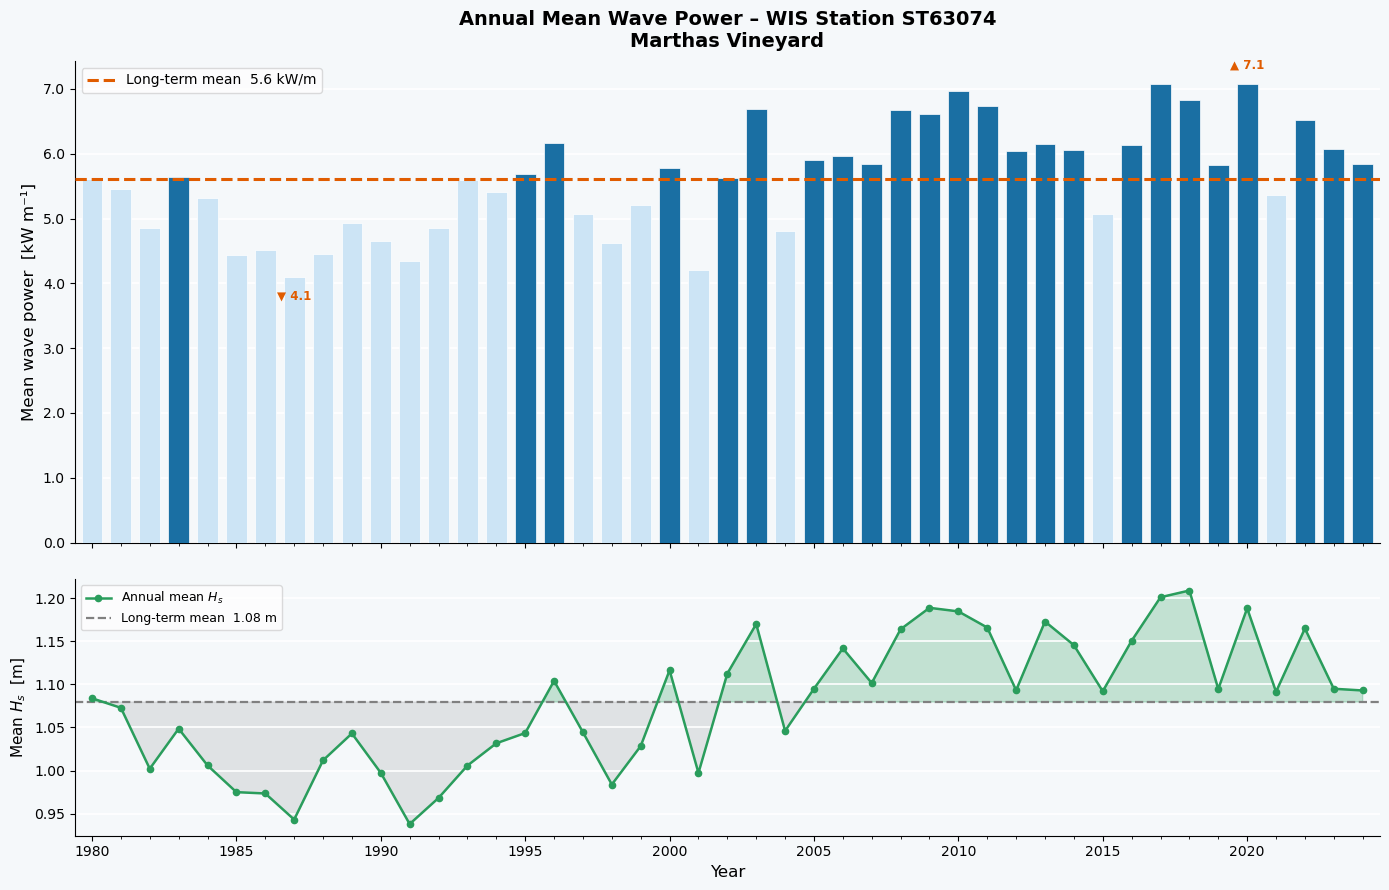

Figure saved → ST63074_wave_power.png


In [7]:
C_BAR, C_ABOVE, C_LINE, C_HS = '#1a6fa3', '#cce4f5', '#e05c00', '#2a9d5c'

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1.6]})
fig.patch.set_facecolor('#f5f8fa')
for ax in axes:
    ax.set_facecolor('#f5f8fa')
    ax.spines[['top','right']].set_visible(False)

years = annual.index.values

# ── Panel 1: annual mean wave power ───────────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(years, annual['P_mean'], width=0.72, zorder=3)
for bar, val in zip(bars, annual['P_mean']):
    bar.set_color(C_BAR if val >= lt_P else C_ABOVE)
    bar.set_edgecolor('white'); bar.set_linewidth(0.5)

ax1.axhline(lt_P, color=C_LINE, lw=2.2, ls='--', zorder=4,
            label=f'Long-term mean  {lt_P:.1f} kW/m')

for idx, va, sym in [(annual['P_mean'].idxmax(), 'bottom', '▲'),
                     (annual['P_mean'].idxmin(), 'top',    '▼')]:
    ax1.annotate(f'{sym} {annual.loc[idx,"P_mean"]:.1f}',
                 xy=(idx, annual.loc[idx,'P_mean']),
                 xytext=(0, 9 if va=='bottom' else -9),
                 textcoords='offset points',
                 ha='center', va=va, fontsize=8.5,
                 color=C_LINE, fontweight='bold')

ax1.set_ylabel('Mean wave power  [kW m⁻¹]', fontsize=12)
ax1.set_title(f'Annual Mean Wave Power – WIS Station ST{STATION_ID}\n' + 
              ISLAND,
              fontsize=14, fontweight='bold', pad=10)
ax1.legend(fontsize=10, framealpha=0.7)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax1.grid(axis='y', color='white', lw=1.2, zorder=2)

# ── Panel 2: annual mean Hs ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(years, annual['Hs_mean'], color=C_HS, lw=1.8,
         marker='o', ms=4.5, zorder=4, label='Annual mean $H_s$')
ax2.fill_between(years, annual['Hs_mean'], lt_Hs,
                 where=annual['Hs_mean'] >= lt_Hs,
                 interpolate=True, alpha=0.25, color=C_HS)
ax2.fill_between(years, annual['Hs_mean'], lt_Hs,
                 where=annual['Hs_mean'] < lt_Hs,
                 interpolate=True, alpha=0.18, color='grey')
ax2.axhline(lt_Hs, color='grey', lw=1.6, ls='--',
            label=f'Long-term mean  {lt_Hs:.2f} m')
ax2.set_ylabel('Mean $H_s$  [m]', fontsize=11)
ax2.set_xlabel('Year', fontsize=12)
ax2.legend(fontsize=9, framealpha=0.7)
ax2.grid(axis='y', color='white', lw=1.2, zorder=2)
ax2.set_xlim(years[0]-0.6, years[-1]+0.6)
ax2.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax2.xaxis.set_minor_locator(mticker.MultipleLocator(1))

plt.tight_layout(h_pad=2)
plt.savefig( 'ST'+STATION_ID + '_wave_power.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → '+'ST'+STATION_ID + '_wave_power.png')

## 7 · Summary table

In [8]:
summary = annual[['Hs_mean','Hs_max','Tp_mean','P_mean','P_max']].copy()
summary.columns = ['Mean Hs (m)','Max Hs (m)','Mean Tp (s)',
                   'Mean P (kW/m)','Max P (kW/m)']
summary.loc['LT Mean'] = summary.mean()
summary.round(2)

,Mean Hs (m),Max Hs (m),Mean Tp (s),Mean P (kW/m),Max P (kW/m)
Year,,,,,
1980,1.08,5.27,6.75,5.61,154.91
1981,1.07,4.79,6.89,5.45,111.87
1982,1.00,4.42,6.78,4.85,88.36
1983,1.05,4.83,6.87,5.64,113.02
1984,1.01,4.20,7.13,5.32,88.84
1985,0.98,7.68,6.37,4.44,398.75
1986,0.97,5.04,6.77,4.51,136.34
1987,0.94,5.04,6.48,4.09,143.99
1988,1.01,3.74,6.65,4.44,58.17


---
### Data source & methods

| Item | Detail |
|---|---|
| **Data** | USACE ERDC Wave Information Studies (WIS) hindcast |
| **Server** | `chldata.erdc.dren.mil` (THREDDS, public, no auth required) |
| **Catalog** | `…/thredds/catalog/wis/Atlantic/ST63218/catalog.html` |
| **File format** | Monthly NetCDF4, hourly resolution |
| **Record** | 1980–2024 (updated annually) |
| **Wave model** | NOAA WAVEWATCH III, CFSR/CFSv2 wind forcing |
| **Power formula** | Deep-water: $P=\\frac{\\rho g^2}{64\\pi}H_s^2 T_e$, $T_e=T_p/1.05$ |
| **Portal API** | `https://wisportal.erdc.dren.mil/data/apidocs` |
| **Contact** | WISinfo@usace.army.mil |